# Суть и тематика проекта: Обнаружение мошенничества в медицинских страховых требованиях

**Источник:** https://www.kaggle.com/datasets/ashaychoudhary/synthetic-health-insurance-claims-fraud-detection



## Оглавление

1. Загружаем данные в формате .csv
2. Изучаем структуру таблицы и типы данных, по которым будем строить доп признаки(см более подробно пункт 6)
3. Анализ целевой переменной Is_Fraudulent
4. Анализ числовых признаков
5. Анализ категориальных признаков
6. Сетевой анализ (графовые признаки)
7. Визуализация сетевых признаков по классам
8. Корреляционная матрица
9. Выбор моделей и метрик для оценки качества (и способов визуализации)
10. Итоговые выводы разведке

## Постановка задачи

**Что мы хотим предсказать?** Была ли медицинская страховая заявка мошеннической (Is_Fraudulent) - это, по сути, задача бинарной классификации


**Целевая переменная:** Is_Fraudulent (1 — мошенничество, 0 — честная заявка)


## Описание входных признаков датасета

### Финансовые признаки 

| Признак | Описание | Связь с мошенничеством |
|---------|----------|------------------------|
| **Claim_Amount** | Сумма страхового требования | Мошенники часто завышают суммы. |
| **Deductible_Amount** | Франшиза — сумма, которую платит пациент  | Аномально низкая/высокая франшиза может указывать на подозрительные схемы |
| **CoPay_Amount** | Сопатеж — дополнительная плата пациента  | Нестандартные значения могут говорить о манипуляциях с оплатой |


### Демографические признаки 

| Признак | Описание | Связь с мошенничеством |
|---------|----------|------------------------|
| **Patient_Age** | Возраст пациента | Некоторые возрастные группы могут быть более уязвимы для мошенничества |
| **Patient_Gender** | Пол пациента | Позволяет выявить, не сфабрикованы ли заявки под "среднего" пациента |


### Клинические признаки 

| Признак | Описание | Связь с мошенничеством |
|---------|----------|------------------------|
| **Number_of_Procedures** | Количество медицинских процедур | Мошенники могут указывать лишние процедуры для увеличения суммы |
| **Length_of_Stay_Days** | Длительность госпитализации (дни) | Несоответствие между диагнозом и сроками лечения — красный флаг |



### Временные признаки (Temporal Features)

| Признак | Описание | Связь с мошенничеством |
|---------|----------|------------------------|
| **Claim_Submitted_Late** | Подана ли заявка с опозданием (True/False) | Мошенники часто затягивают подачу, надеясь, что проверка будет менее тщательной |



### Географические признаки (Geographic Features)

| Признак | Описание | Связь с мошенничеством |
|---------|----------|------------------------|
| **Provider_Patient_Distance_Miles** | Расстояние между местом жительства пациента и провайдером (мили) | Мошенники могут специально ездить далеко к "своим" врачам. Аномально большое расстояние = потенциальный фрод |


- **Сетевые, которые мы сами создадим:** 
  - patient_num_hospitals — сколько разных больниц посетил пациент
  - patient_num_providers — сколько разных провайдеров
  - provider_num_patients — сколько пациентов у провайдера
  - hospital_num_patients — сколько пациентов в больнице

## Выбор моделей для последующего моделирования

| Модель | Обоснование |
|--------|-------------|
| **XGBoost** | устойчива к выбросам, которых в наших данных, пусть и синтетических, но все-таки будет немало  |
| **Random Forest** | устойчива к переобучению, хорошо работает с разными масштабами данных |
| **Logistic Regression** | По сути будет бенчмарком, с которым будем сравнивать |

## Выбор метрик оценки качества

| Метрика | Почему важна |
|---------|--------------|
| **F1-Score** | Баланс точности и полноты |
| **ROC-AUC** | Разделяющая способность модели |
| **Precision** | Не обвинять честные заявки (это хоть и разряд уже комплаенс-деятельности, но нам тоже пригодится) |
| **Recall** | Поймать максимум мошенников |
| **Confusion Matrix** | Визуальный анализ ошибок |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
np.random.seed(42)

print("Библиотеки загружены")
print(f"Версия pandas: {pd.__version__}")

Библиотеки загружены
Версия pandas: 2.3.3


## 2. Загрузка данных



In [15]:
df = pd.read_csv("data.csv")
print("Грузим данные")
print(f"Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} столбцов")

df.head(3)

Грузим данные
Размер датасета: 1,000,000 строк, 30 столбцов


,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,Patient_State,Hospital_ID,Provider_Type,Provider_Specialty,Provider_City,Provider_State,Diagnosis_Code,Procedure_Code,Number_of_Procedures,Admission_Type,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
0,50841848,POL000000000,100000000,10/01/2021,09/28/2021,05/13/2024,2512.36,63,Male,Houston,MD,4030,Specialist,Gastroenterology,Columbus,VA,C23,38863,1,Newborn,Long-Term Care,1,Outpatient,137.19,42.25,6,0,33.55,False,False
1,52114874,POL000000001,100000001,05/10/2020,04/13/2020,12/22/2021,5304.96,48,Female,Los Angeles,WI,2946,Specialist,General Surgery,Indianapolis,TX,M42,13141,1,Emergency,Home,7,Outpatient,326.29,218.89,9,18,138.03,False,False
2,14459272,POL000000002,100000002,01/07/2022,12/01/2021,12/31/2023,19618.05,56,Female,Philadelphia,LA,1249,Pharmacy,Orthopedics,Newark,MA,N78,18710,7,Urgent,Home,11,Inpatient,251.14,269.87,11,95,522.52,True,True


## 3. Структура таблицы и типы данных

Проверяем типы данных, пропуски и дубликаты.

In [18]:
print("1. СТРУКТУРА ТАБЛИЦЫ И ТИПЫ ДАННЫХ")
print("\nТипы данных:")
print(df.dtypes)
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)
print("\nПроверка пропусков:")
print(missing[missing["missing_count"] > 0])
print("\nКоличество дубликатов:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nРазмер после удаления дубликатов: {df.shape[0]:,} строк, {df.shape[1]} столбцов")

1. СТРУКТУРА ТАБЛИЦЫ И ТИПЫ ДАННЫХ

Типы данных:
Patient_ID                              int64
Policy_Number                          object
Claim_ID                                int64
Claim_Date                             object
Service_Date                           object
Policy_Expiration_Date                 object
Claim_Amount                          float64
Patient_Age                             int64
Patient_Gender                         object
Patient_City                           object
Patient_State                          object
Hospital_ID                             int64
Provider_Type                          object
Provider_Specialty                     object
Provider_City                          object
Provider_State                         object
Diagnosis_Code                         object
Procedure_Code                          int64
Number_of_Procedures                    int64
Admission_Type                         object
Discharge_Type                 

## 4. Анализ целевой переменной Is_Fraudulent

Проверяем сбалансированность классов.

**Важное замечание:** Данные синтетические, поэтому классы сбалансированы 50/50. В реальных страховых данных доля мошенничества составляет 3-15%.

2. РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

Распределение:
   Не фрод (0): 500,000 заявок (50.0%)
   Фрод (1):   500,000 заявок (50.0%)


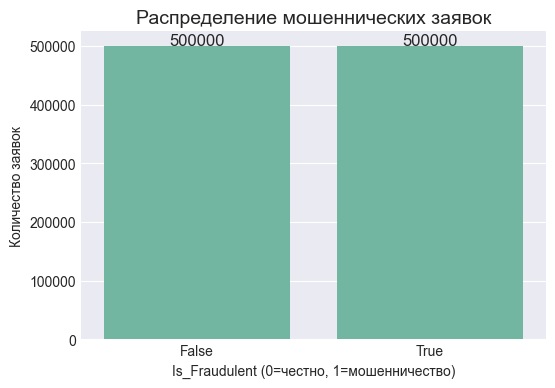


Вывод: Классы сбалансированы (50/50) из-за синтетической природы данных.
   Основными метриками будут F1-Score и ROC-AUC.


In [5]:
print("2. РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
fraud_counts = df['Is_Fraudulent'].value_counts()
fraud_pct = df['Is_Fraudulent'].value_counts(normalize=True) * 100
print(f"\nРаспределение:")
print(f"   Не фрод (0): {fraud_counts[0]:,} заявок ({fraud_pct[0]:.1f}%)")
print(f"   Фрод (1):   {fraud_counts[1]:,} заявок ({fraud_pct[1]:.1f}%)")
plt.figure(figsize=(6,4))
sns.countplot(x='Is_Fraudulent', data=df)
plt.title('Распределение мошеннических заявок', fontsize=14)
plt.xlabel('Is_Fraudulent (0=честно, 1=мошенничество)')
plt.ylabel('Количество заявок')
for i, count in enumerate(fraud_counts):
    plt.text(i, count + 1000, str(count), ha='center', fontsize=12)
plt.show()
print("\nВывод: Классы сбалансированы (50/50) из-за синтетической природы данных.")
print("   Основными метриками будут F1-Score и ROC-AUC.")

## Работа с выбросами

### Специфика медицинских страховых данных

В медицинских страховых данных выбросы не всегда являются ошибками. Они будут своего рода индикаторами фрода или хотя бы того, что имеет смысл рассмотреть случай. Например:
Очень высокие значения Claim_Amount, Number_of_Procedures или Length_of_Stay_Days могут соответствовать:

-Либо реальным сложным медицинским случаям, то есть - дорогостоящие операции, длительное лечение
-Либо мошенническим схемам, вроде завышения сумм или фиктивных процедур

Поэтому мы хотим:

1. найти выбросы с помощью boxplot и метода IQR для ключевых признаков - про сами методы лучше, вероятно, рассказать в рамках презентации
2. оценить, в каких признаках выбросов больше всего
3. сравнить долю выбросов среди мошеннических и честных заявок


АНАЛИЗ ВЫБРОСОВ
                        feature  total_outliers  total_percent  fraud_outliers  fraud_percent  legit_outliers  legit_percent
                   Claim_Amount           92944           9.29           40238           8.05           38930           7.79
           Number_of_Procedures               0           0.00               0           0.00               0           0.00
            Length_of_Stay_Days               0           0.00               0           0.00               0           0.00
Provider_Patient_Distance_Miles               0           0.00               0           0.00               0           0.00


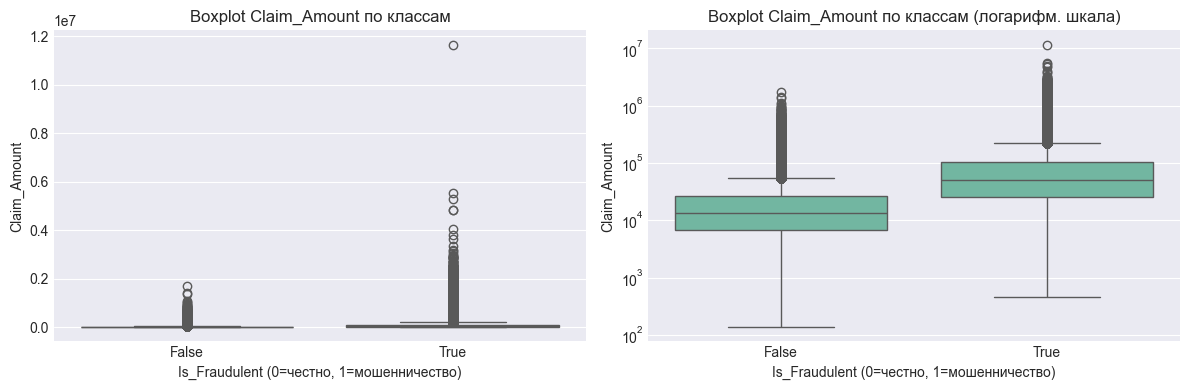

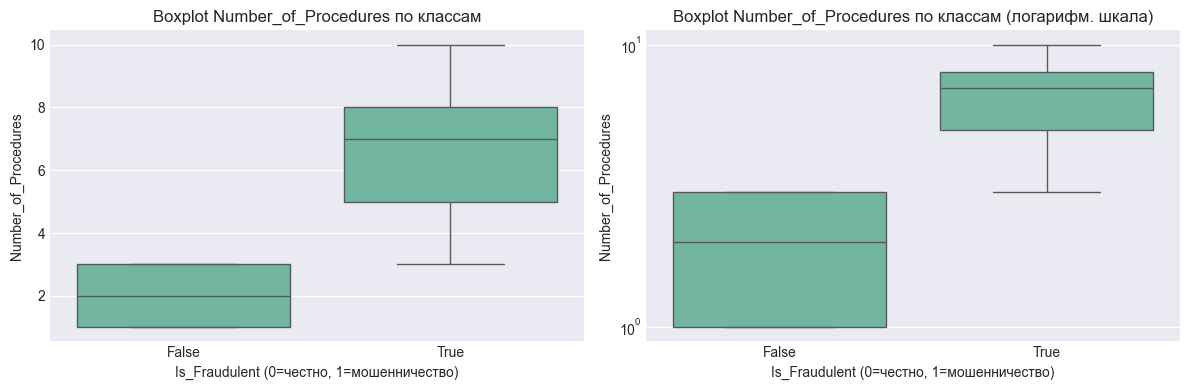

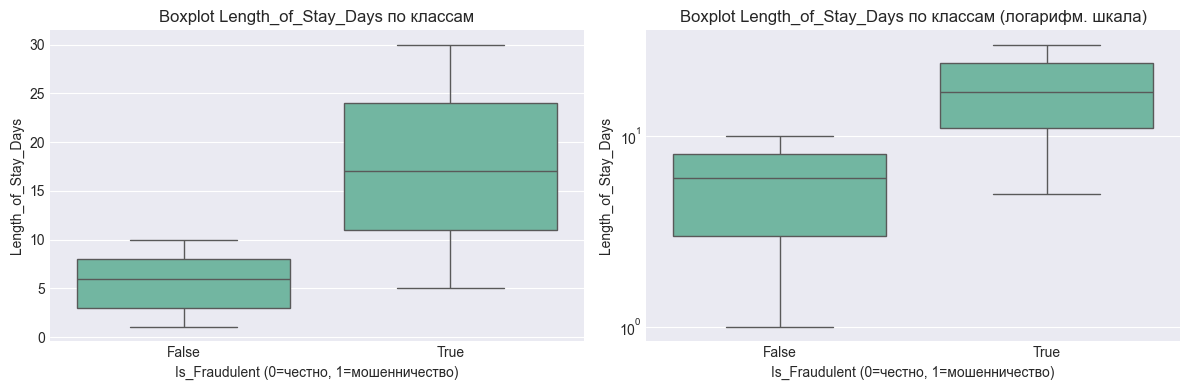

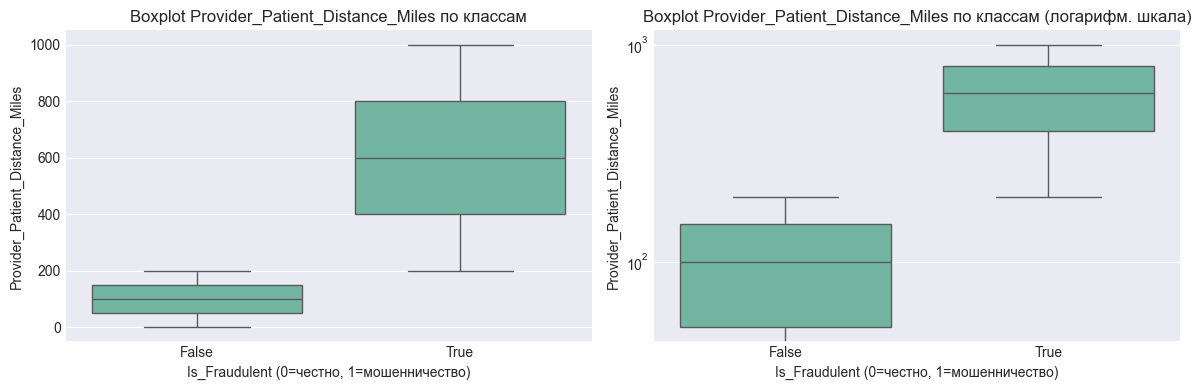

In [17]:
print("АНАЛИЗ ВЫБРОСОВ")
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), len(outliers) / len(data) * 100
features_for_outliers = [
    'Claim_Amount', 'Number_of_Procedures', 'Length_of_Stay_Days',
    'Provider_Patient_Distance_Miles'
]
features_for_outliers = [col for col in features_for_outliers if col in df.columns]

outlier_info = []
for col in features_for_outliers:
    count, percent = count_outliers_iqr(df, col)
    count_fraud, percent_fraud = count_outliers_iqr(df[df['Is_Fraudulent'] == 1], col)
    count_legit, percent_legit = count_outliers_iqr(df[df['Is_Fraudulent'] == 0], col)
    
    outlier_info.append({
        'feature': col,
        'total_outliers': count,
        'total_percent': round(percent, 2),
        'fraud_outliers': count_fraud,
        'fraud_percent': round(percent_fraud, 2),
        'legit_outliers': count_legit,
        'legit_percent': round(percent_legit, 2)
    })

outlier_df = pd.DataFrame(outlier_info)
print(outlier_df.to_string(index=False))
for col in features_for_outliers:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    sns.boxplot(x='Is_Fraudulent', y=col, data=df)
    plt.title(f'Boxplot {col} по классам')
    plt.xlabel('Is_Fraudulent (0=честно, 1=мошенничество)')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x='Is_Fraudulent', y=col, data=df)
    plt.yscale('log')
    plt.title(f'Boxplot {col} по классам (логарифм. шкала)')
    plt.xlabel('Is_Fraudulent (0=честно, 1=мошенничество)')
    
    plt.tight_layout()
    plt.show()

## 5. Анализ числовых признаков

Смотрим распределения и связь с целевой переменной.

3. АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ
Анализируемые числовые признаки: ['Claim_Amount', 'Patient_Age', 'Hospital_ID', 'Procedure_Code', 'Number_of_Procedures', 'Length_of_Stay_Days', 'Deductible_Amount', 'CoPay_Amount', 'Number_of_Previous_Claims_Patient', 'Number_of_Previous_Claims_Provider', 'Provider_Patient_Distance_Miles']

Статистика Claim_Amount:
count    1.000000e+06
mean     5.509740e+04
std      9.487515e+04
min      1.357900e+02
25%      1.112787e+04
50%      2.578898e+04
75%      6.094032e+04
max      1.164850e+07
Name: Claim_Amount, dtype: float64


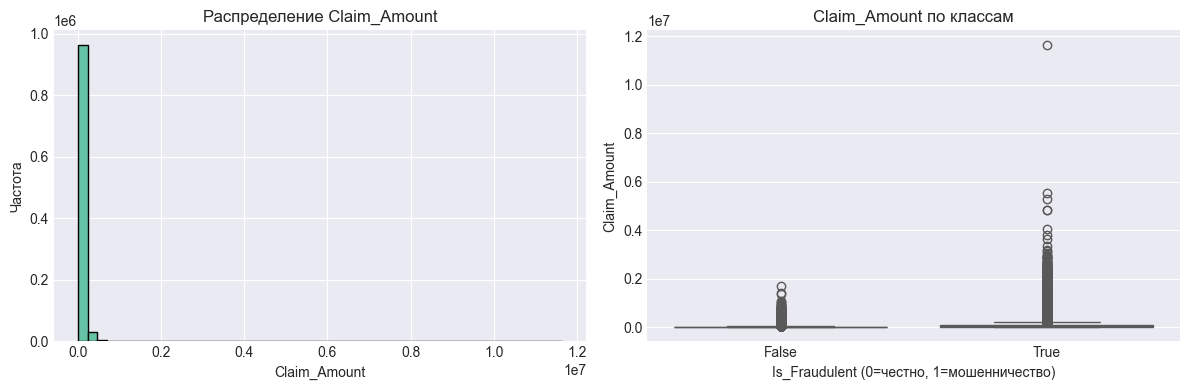


Статистика Patient_Age:
count    1000000.000000
mean          57.744520
std           18.166505
min           18.000000
25%           46.000000
50%           59.000000
75%           72.000000
max           89.000000
Name: Patient_Age, dtype: float64


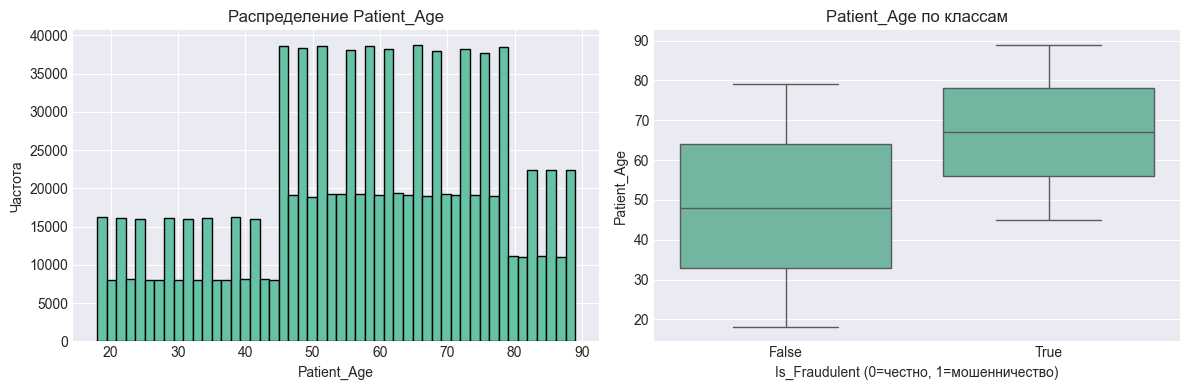


Статистика Hospital_ID:
count    1000000.000000
mean        2501.135956
std         1442.576411
min            1.000000
25%         1251.000000
50%         2503.000000
75%         3749.000000
max         5000.000000
Name: Hospital_ID, dtype: float64


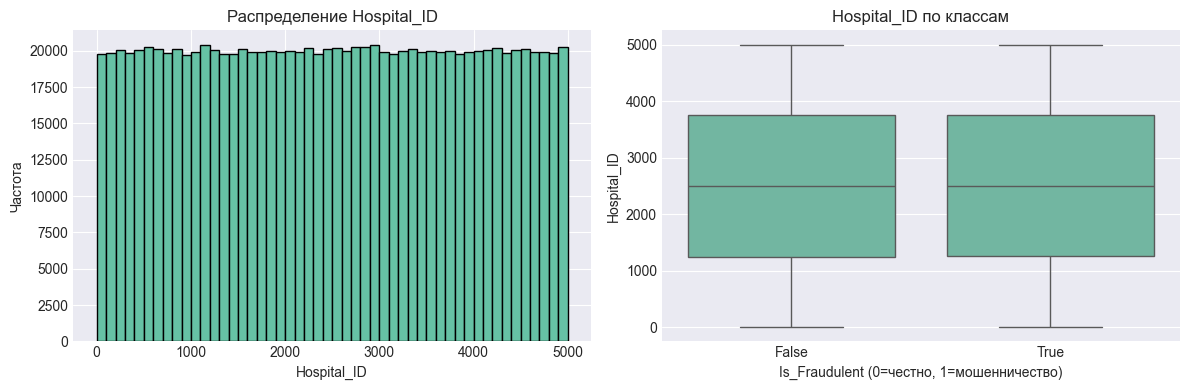


Статистика Procedure_Code:
count    1000000.000000
mean       55004.961578
std        25971.452113
min        10000.000000
25%        32553.750000
50%        55009.000000
75%        77486.000000
max        99998.000000
Name: Procedure_Code, dtype: float64


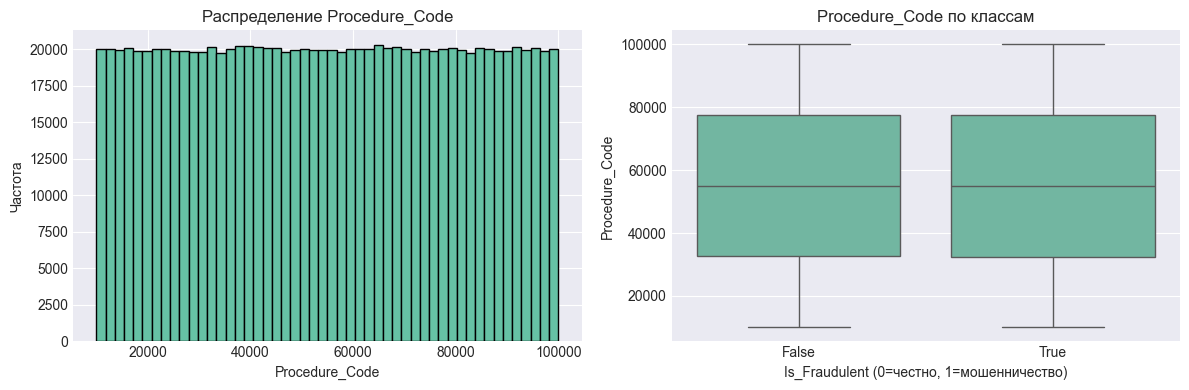


Статистика Number_of_Procedures:
count    1000000.000000
mean           4.250136
std            2.833276
min            1.000000
25%            2.000000
50%            3.000000
75%            7.000000
max           10.000000
Name: Number_of_Procedures, dtype: float64


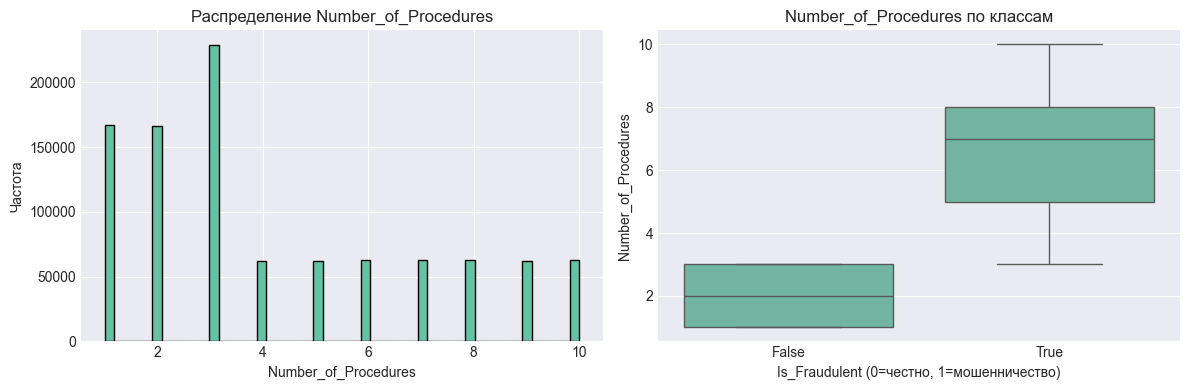


Статистика Length_of_Stay_Days:
count    1000000.000000
mean          11.493020
std            8.257167
min            1.000000
25%            5.000000
50%            9.000000
75%           17.000000
max           30.000000
Name: Length_of_Stay_Days, dtype: float64


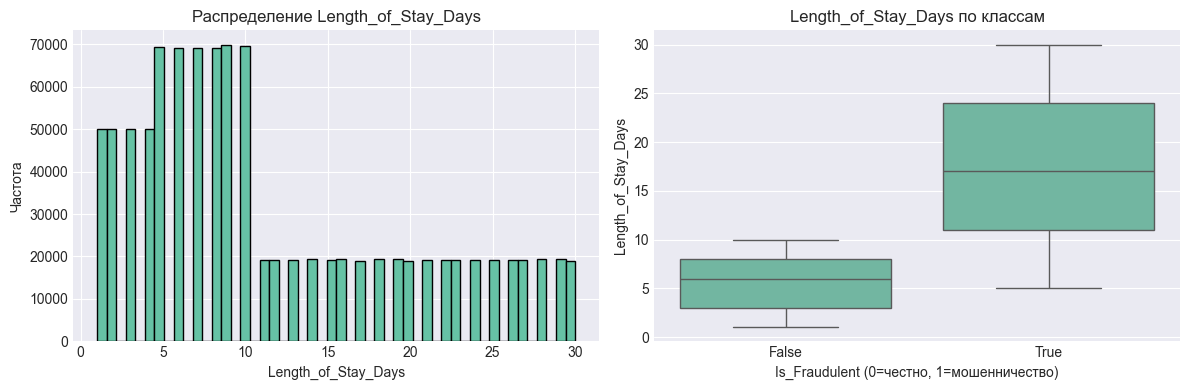

In [6]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
ignore_cols = ['Patient_ID', 'Policy_Number', 'Claim_ID', 'Is_Fraudulent']
numeric_features = [col for col in numeric_features if col not in ignore_cols]
print("3. АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ")
print(f"Анализируемые числовые признаки: {numeric_features}")
for col in numeric_features[:6]:
    print(f"\nСтатистика {col}:")
    print(df[col].describe())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 
    axes[0].hist(df[col].dropna(), bins=50, edgecolor='black')
    axes[0].set_title(f'Распределение {col}', fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Частота')
    sns.boxplot(x='Is_Fraudulent', y=col, data=df, ax=axes[1])
    axes[1].set_title(f'{col} по классам', fontsize=12)
    axes[1].set_xlabel('Is_Fraudulent (0=честно, 1=мошенничество)')
    axes[1].set_ylabel(col)
    plt.tight_layout()
    plt.show()

## 6. Анализ категориальных признаков

4. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Анализируемые категориальные признаки: ['Patient_Gender', 'Patient_City', 'Patient_State', 'Provider_Type', 'Provider_Specialty', 'Provider_City', 'Provider_State', 'Diagnosis_Code', 'Admission_Type', 'Discharge_Type', 'Service_Type']


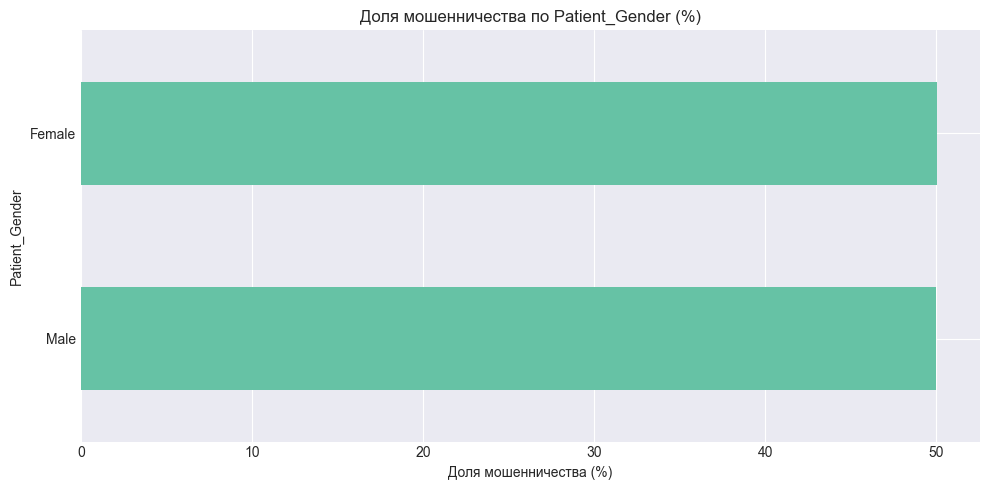

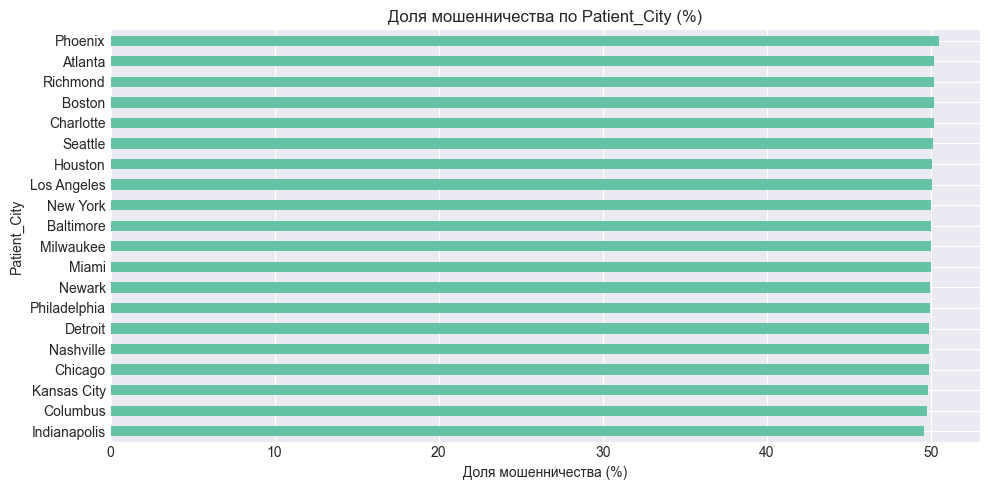

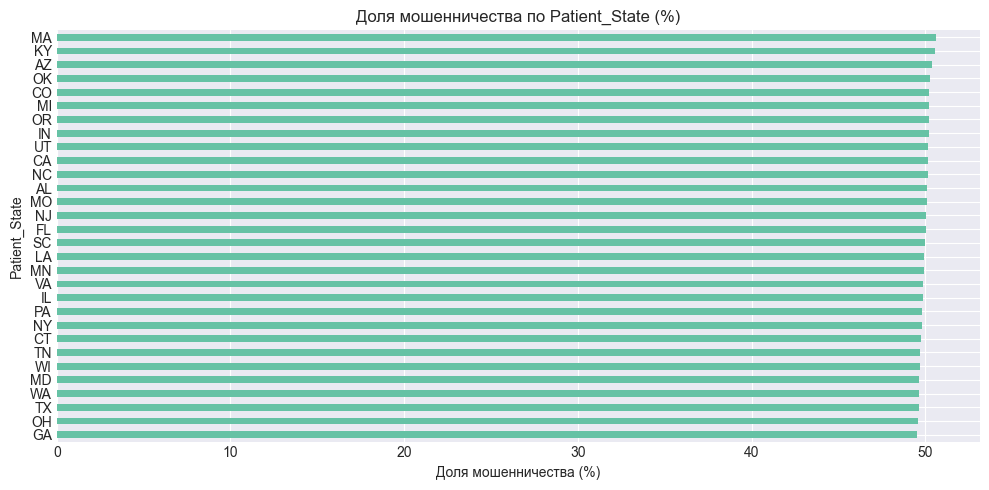

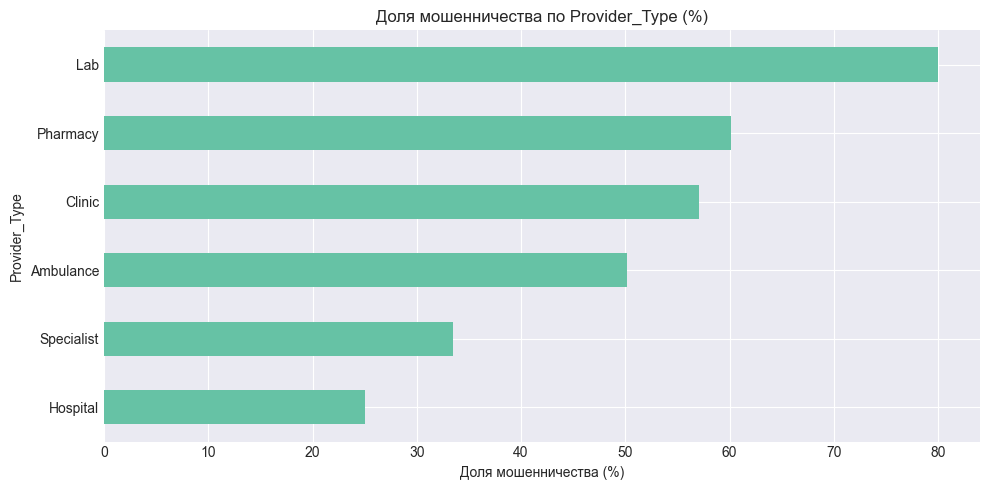

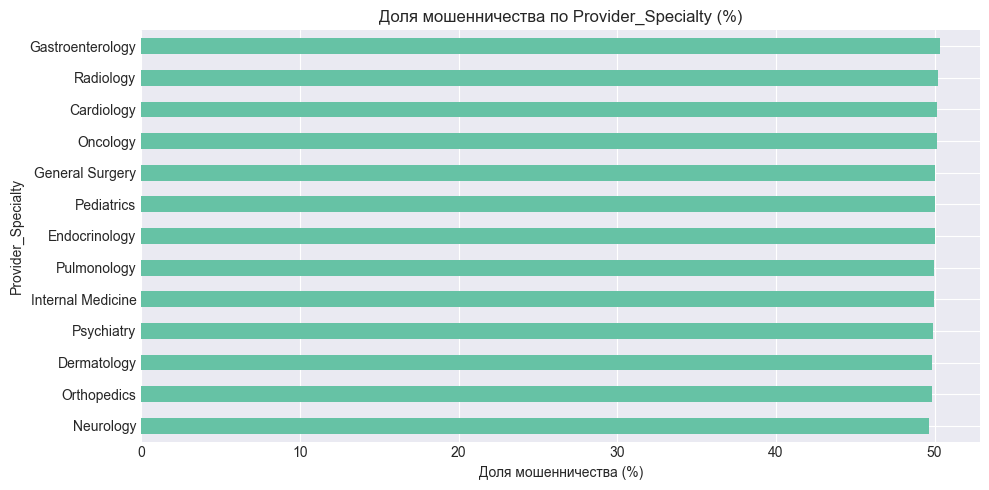

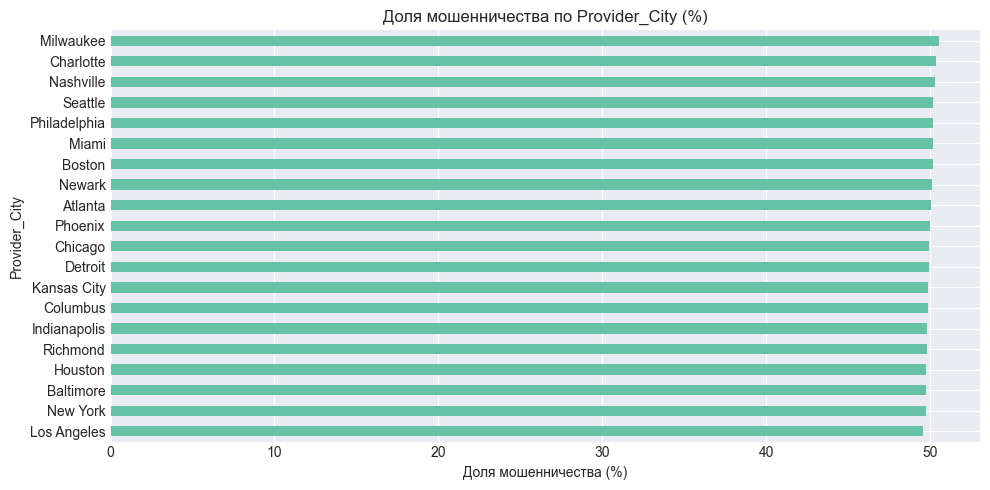

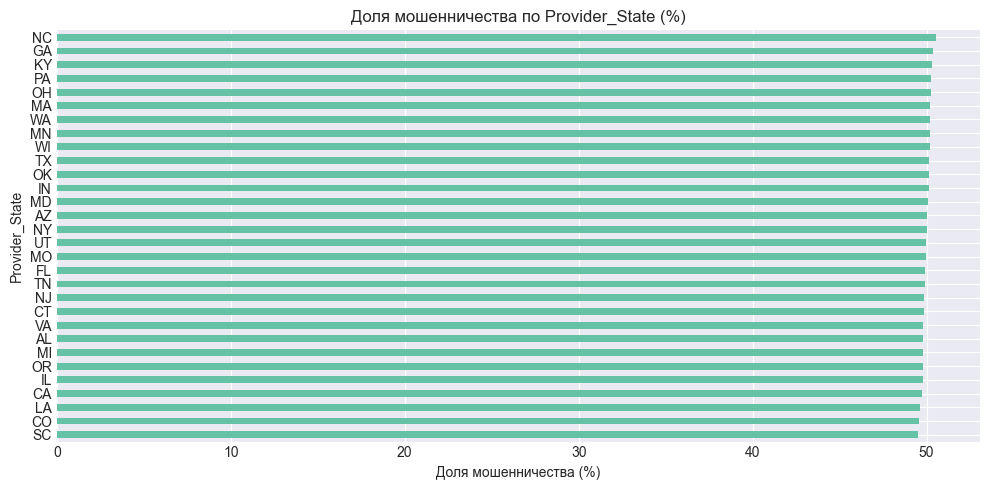

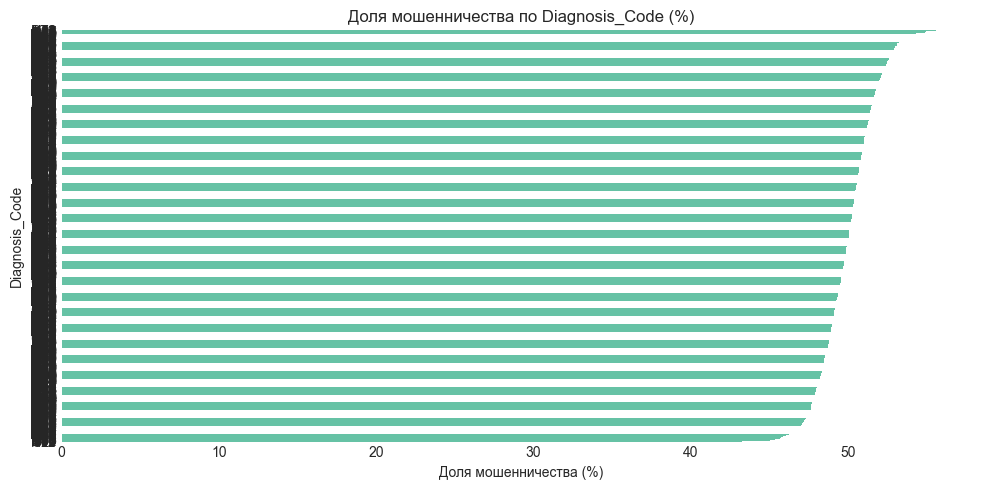

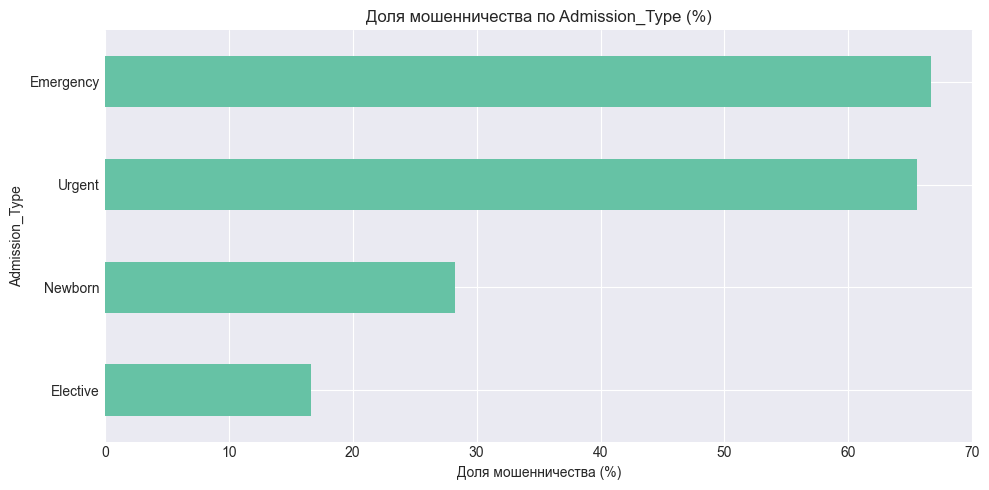

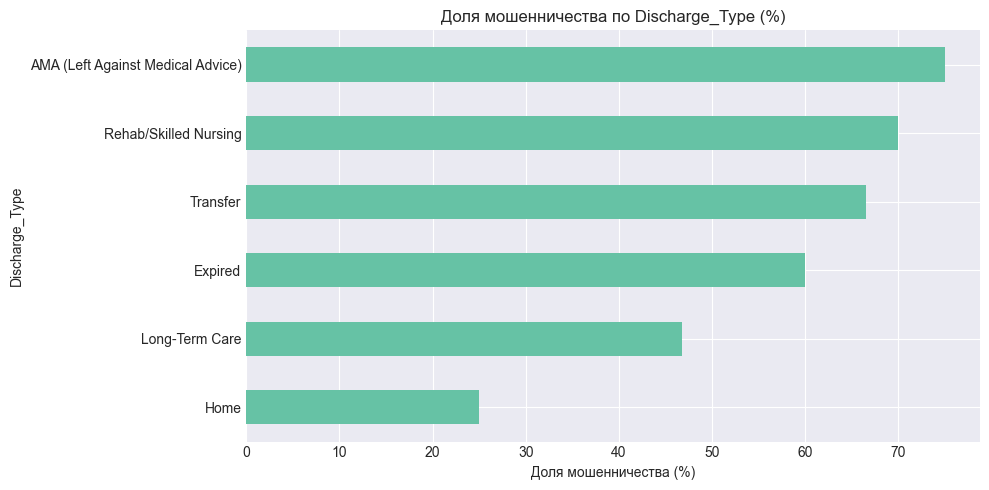

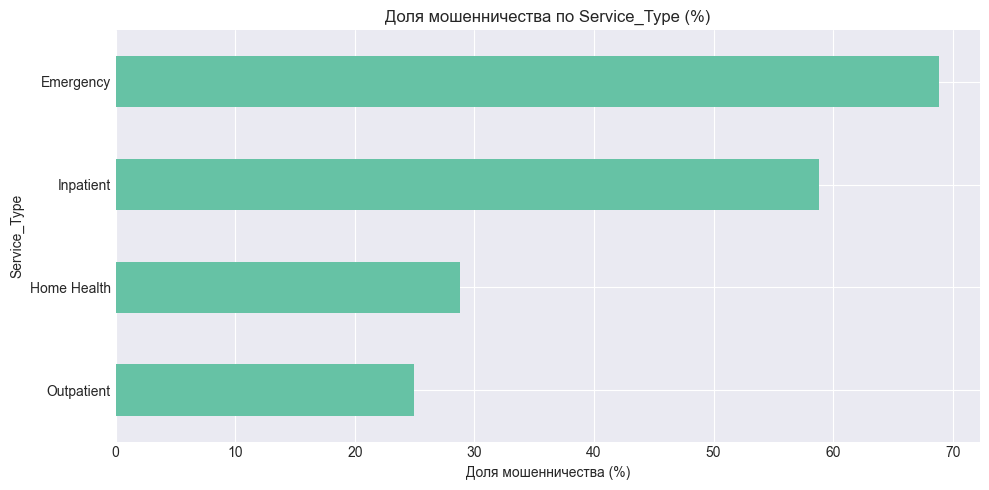

In [7]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
ignore_cat = ['Patient_ID', 'Policy_Number', 'Claim_ID', 'Claim_Date', 'Service_Date', 'Policy_Expiration_Date']
categorical_features = [col for col in categorical_features if col not in ignore_cat]
print("4. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print(f"Анализируемые категориальные признаки: {categorical_features}")
for col in categorical_features:
    plt.figure(figsize=(10, 5))
    fraud_by_cat = df.groupby(col)['Is_Fraudulent'].mean() * 100
    fraud_by_cat.sort_values().plot(kind='barh')
    plt.title(f'Доля мошенничества по {col} (%)', fontsize=12)
    plt.xlabel('Доля мошенничества (%)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 7. Сетевой анализ — создание графовых признаков

**Мы хотим с поработать с этим  методом по трем основным причинам:** 
- Мошенничество часто проявляется в виде коллюзионных схем (сговор пациентов с провайдерами)
- Стандартные модели смотрят на заявки изолированно и не видят, что один пациент посетил 10 разных больниц за неделю
- Сетевые признаки позволяют выявить эти аномалии

ЧТобы не создавать лишних признаков, мы только будем смотреть, какие ID-колонки есть в данных, и генерировать признаки только на их основе.


Суть метода в чем: вот например, мы - нанятый страховой следователь. Можно пойти двумя путями:
1) смотрим на каждую заявку отдельно: Сумма 500, диагноз грипп — нормально - но очень муторно и как я уже упоминала выше: существуют схемы, в которых присутствует сговор клиента и самого страховщика, такие схемы можно распознать только изучая всю картину целиком. И хоть граф мы строить не умеем и не будем, нам нужны лишь числовые характеристики, которые описывают положение узла в сети.
2) С сетевым анализом мы видим сразу всю ситуацию по типу:
    а) Этот пациент за месяц посетил 8 разных больниц
    б) Этот врач выписал счета на $1M за один день
    в) Эти 10 пациентов лечились в одной больнице с одинаковыми диагнозами

In [19]:
print("5. СЕТЕВОЙ АНАЛИЗ — СОЗДАНИЕ ГРАФОВЫХ ПРИЗНАКОВ")
all_graph_features = []
print("\nДоступные колонки в датасете:")
print(df.columns.tolist())
patient_features = df.groupby('Patient_ID').agg({
    'Claim_ID': 'count',
}).reset_index()
patient_features.columns = ['Patient_ID', 'patient_total_claims']
if 'Hospital_ID' in df.columns:
    hospital_count = df.groupby('Patient_ID')['Hospital_ID'].nunique().reset_index()
    hospital_count.columns = ['Patient_ID', 'patient_num_hospitals']
    patient_features = patient_features.merge(hospital_count, on='Patient_ID', how='left')
    all_graph_features.append('patient_num_hospitals')
    print("Создан признак: patient_num_hospitals")
if 'Provider_ID' in df.columns:
    provider_count = df.groupby('Patient_ID')['Provider_ID'].nunique().reset_index()
    provider_count.columns = ['Patient_ID', 'patient_num_providers']
    patient_features = patient_features.merge(provider_count, on='Patient_ID', how='left')
    all_graph_features.append('patient_num_providers')
    print("Создан признак: patient_num_providers")
claim_avg = df.groupby('Patient_ID')['Claim_Amount'].mean().reset_index()
claim_avg.columns = ['Patient_ID', 'patient_avg_claim']
patient_features = patient_features.merge(claim_avg, on='Patient_ID', how='left')
all_graph_features.append('patient_avg_claim')
claim_sum = df.groupby('Patient_ID')['Claim_Amount'].sum().reset_index()
claim_sum.columns = ['Patient_ID', 'patient_total_claim']
patient_features = patient_features.merge(claim_sum, on='Patient_ID', how='left')
all_graph_features.append('patient_total_claim')
if 'Provider_Patient_Distance_Miles' in df.columns:
    distance_mean = df.groupby('Patient_ID')['Provider_Patient_Distance_Miles'].mean().reset_index()
    distance_mean.columns = ['Patient_ID', 'patient_avg_distance']
    patient_features = patient_features.merge(distance_mean, on='Patient_ID', how='left')
    all_graph_features.append('patient_avg_distance')
    print("Создан признак: patient_avg_distance")
print(f"\nСоздано признаков уровня пациента: {len(patient_features.columns)-1}")
if 'Provider_ID' in df.columns:
    provider_features = df.groupby('Provider_ID').agg({
        'Claim_ID': 'count',
    }).reset_index()
    provider_features.columns = ['Provider_ID', 'provider_total_claims']
    patient_count_provider = df.groupby('Provider_ID')['Patient_ID'].nunique().reset_index()
    patient_count_provider.columns = ['Provider_ID', 'provider_num_patients']
    provider_features = provider_features.merge(patient_count_provider, on='Provider_ID', how='left')
    all_graph_features.append('provider_num_patients')
    claim_avg_provider = df.groupby('Provider_ID')['Claim_Amount'].mean().reset_index()
    claim_avg_provider.columns = ['Provider_ID', 'provider_avg_claim']
    provider_features = provider_features.merge(claim_avg_provider, on='Provider_ID', how='left')
    all_graph_features.append('provider_avg_claim')
    print(f"Создано признаков уровня провайдера: {len(provider_features.columns)-1}")
else:
    provider_features = None
    print("Колонка Provider_ID не найдена — признаки провайдера пропущены")
if 'Hospital_ID' in df.columns:
    hospital_features = df.groupby('Hospital_ID').agg({
        'Claim_ID': 'count',
    }).reset_index()
    hospital_features.columns = ['Hospital_ID', 'hospital_total_claims']
    patient_count_hospital = df.groupby('Hospital_ID')['Patient_ID'].nunique().reset_index()
    patient_count_hospital.columns = ['Hospital_ID', 'hospital_num_patients']
    hospital_features = hospital_features.merge(patient_count_hospital, on='Hospital_ID', how='left')
    all_graph_features.append('hospital_num_patients')
    claim_avg_hospital = df.groupby('Hospital_ID')['Claim_Amount'].mean().reset_index()
    claim_avg_hospital.columns = ['Hospital_ID', 'hospital_avg_claim']
    hospital_features = hospital_features.merge(claim_avg_hospital, on='Hospital_ID', how='left')
    all_graph_features.append('hospital_avg_claim')
    print(f"Создано признаков уровня больницы: {len(hospital_features.columns)-1}")
else:
    hospital_features = None
    print("Колонка Hospital_ID не найдена — признаки больницы пропущены")
df_analysis = df.copy()
df_analysis = df_analysis.merge(patient_features, on='Patient_ID', how='left')
if provider_features is not None:
    df_analysis = df_analysis.merge(provider_features, on='Provider_ID', how='left')
if hospital_features is not None:
    df_analysis = df_analysis.merge(hospital_features, on='Hospital_ID', how='left')
print(f"\nРазмер датасета после добавления сетевых признаков: {df_analysis.shape[0]:,} строк")
print(f"Созданные сетевые признаки: {all_graph_features}")

5. СЕТЕВОЙ АНАЛИЗ — СОЗДАНИЕ ГРАФОВЫХ ПРИЗНАКОВ

Доступные колонки в датасете:
['Patient_ID', 'Policy_Number', 'Claim_ID', 'Claim_Date', 'Service_Date', 'Policy_Expiration_Date', 'Claim_Amount', 'Patient_Age', 'Patient_Gender', 'Patient_City', 'Patient_State', 'Hospital_ID', 'Provider_Type', 'Provider_Specialty', 'Provider_City', 'Provider_State', 'Diagnosis_Code', 'Procedure_Code', 'Number_of_Procedures', 'Admission_Type', 'Discharge_Type', 'Length_of_Stay_Days', 'Service_Type', 'Deductible_Amount', 'CoPay_Amount', 'Number_of_Previous_Claims_Patient', 'Number_of_Previous_Claims_Provider', 'Provider_Patient_Distance_Miles', 'Claim_Submitted_Late', 'Is_Fraudulent']
Создан признак: patient_num_hospitals
Создан признак: patient_avg_distance

Создано признаков уровня пациента: 5
Колонка Provider_ID не найдена — признаки провайдера пропущены
Создано признаков уровня больницы: 3

Размер датасета после добавления сетевых признаков: 1,000,000 строк
Созданные сетевые признаки: ['patient_num_hos

## 8. Статистика и визуализация сетевых признаков

Посмотрим, как сетевые признаки распределены среди мошеннических и честных заявок.

Статистика по сетевым признакам:

patient_num_hospitals:
  Среднее: 1.01
  Медиана: 1.00
  Максимум: 3.00
  Медиана при фроде: 1.00
  Медиана при честных: 1.00

patient_avg_claim:
  Среднее: 55097.40
  Медиана: 25899.44
  Максимум: 11648500.33
  Медиана при фроде: 51239.83
  Медиана при честных: 13459.06

patient_total_claim:
  Среднее: 55708.62
  Медиана: 26117.50
  Максимум: 11648500.33
  Медиана при фроде: 51684.78
  Медиана при честных: 13529.60

patient_avg_distance:
  Среднее: 350.04
  Медиана: 203.27
  Максимум: 1000.00
  Медиана при фроде: 597.87
  Медиана при честных: 100.66

hospital_num_patients:
  Среднее: 201.00
  Медиана: 201.00
  Максимум: 250.00
  Медиана при фроде: 201.00
  Медиана при честных: 201.00

hospital_avg_claim:
  Среднее: 55097.40
  Медиана: 54488.86
  Максимум: 109172.06
  Медиана при фроде: 54674.76
  Медиана при честных: 54340.32

Визуализация распределения сетевых признаков по классам


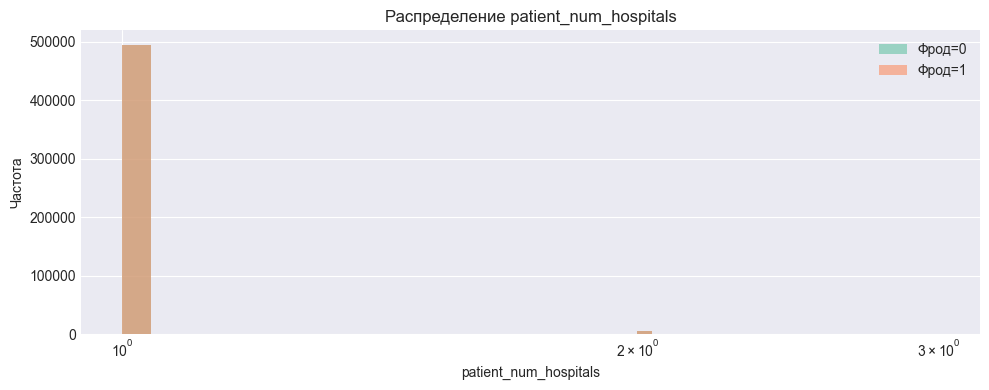

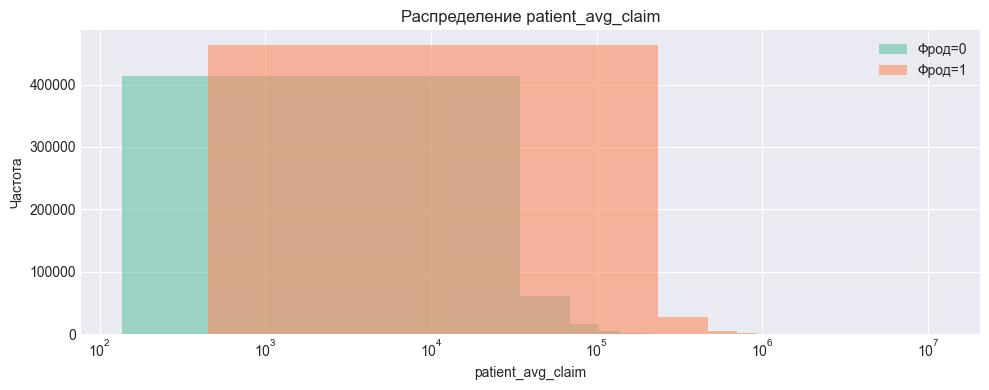

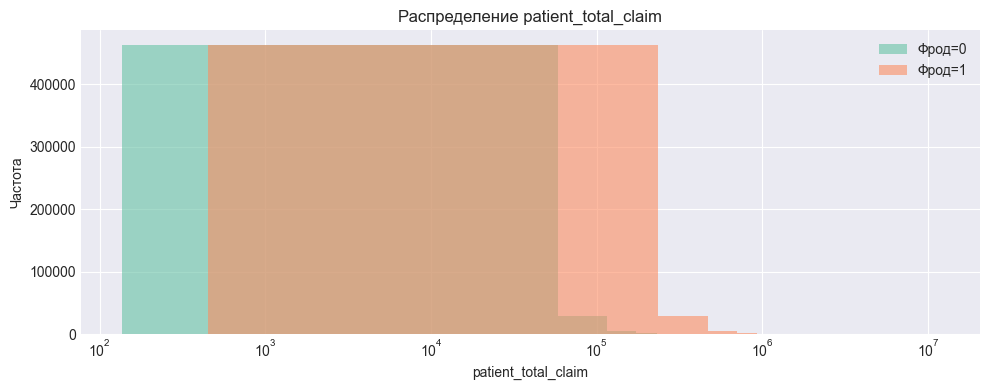

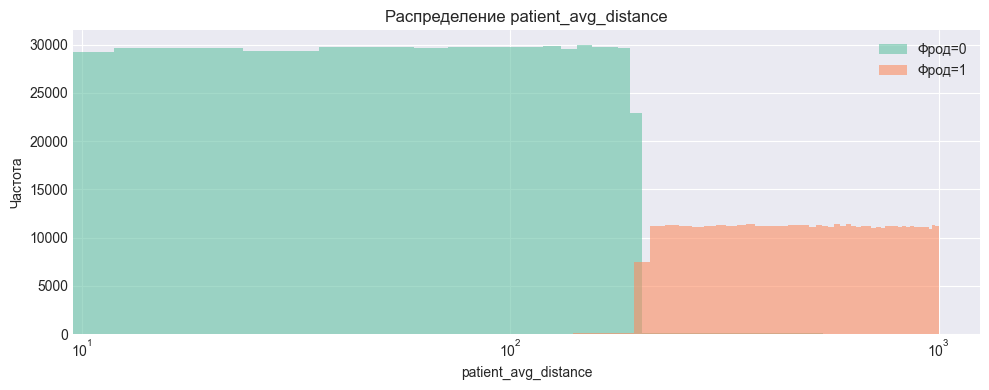

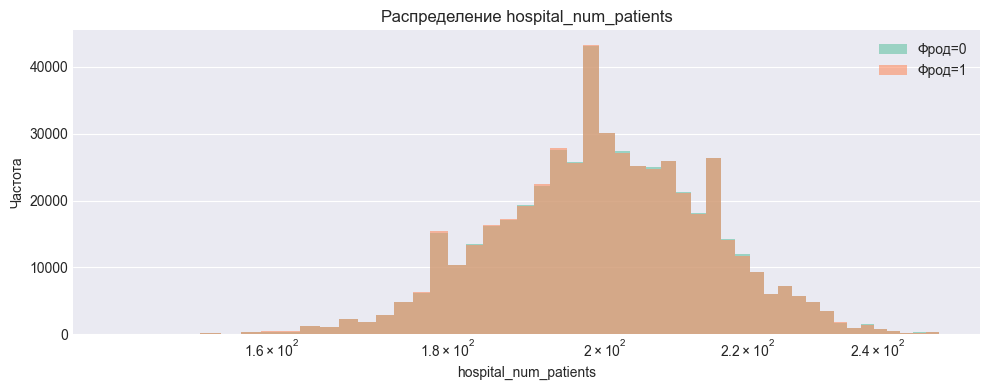

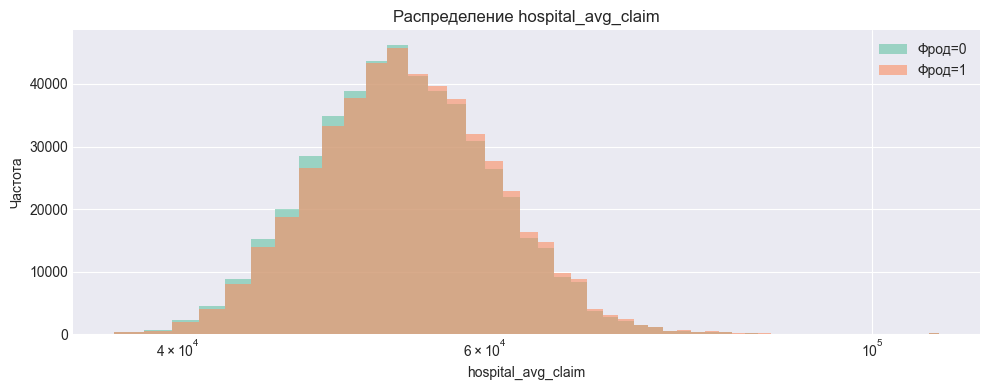

In [21]:
print("Статистика по сетевым признакам:")
for col in all_graph_features:
    if col in df_analysis.columns:
        print(f"\n{col}:")
        print(f"  Среднее: {df_analysis[col].mean():.2f}")
        print(f"  Медиана: {df_analysis[col].median():.2f}")
        print(f"  Максимум: {df_analysis[col].max():.2f}")
        fraud_median = df_analysis[df_analysis['Is_Fraudulent'] == 1][col].median()
        legit_median = df_analysis[df_analysis['Is_Fraudulent'] == 0][col].median()
        print(f"  Медиана при фроде: {fraud_median:.2f}")
        print(f"  Медиана при честных: {legit_median:.2f}")
print("\nВизуализация распределения сетевых признаков по классам")
for col in all_graph_features:
    if col in df_analysis.columns:
        plt.figure(figsize=(10, 4))
        for fraud_class in [0, 1]:
            subset = df_analysis[df_analysis['Is_Fraudulent'] == fraud_class][col].dropna()
            plt.hist(subset, bins=50, alpha=0.6, label=f'Фрод={fraud_class}')
        plt.xscale('log')
        plt.title(f'Распределение {col}', fontsize=12)
        plt.xlabel(col)
        plt.ylabel('Частота')
        plt.legend()
        plt.tight_layout()
        plt.show()

## 9. Корреляционный анализ

Строим корреляционную матрицу для числовых признаков, включая созданные сетевые.

6. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


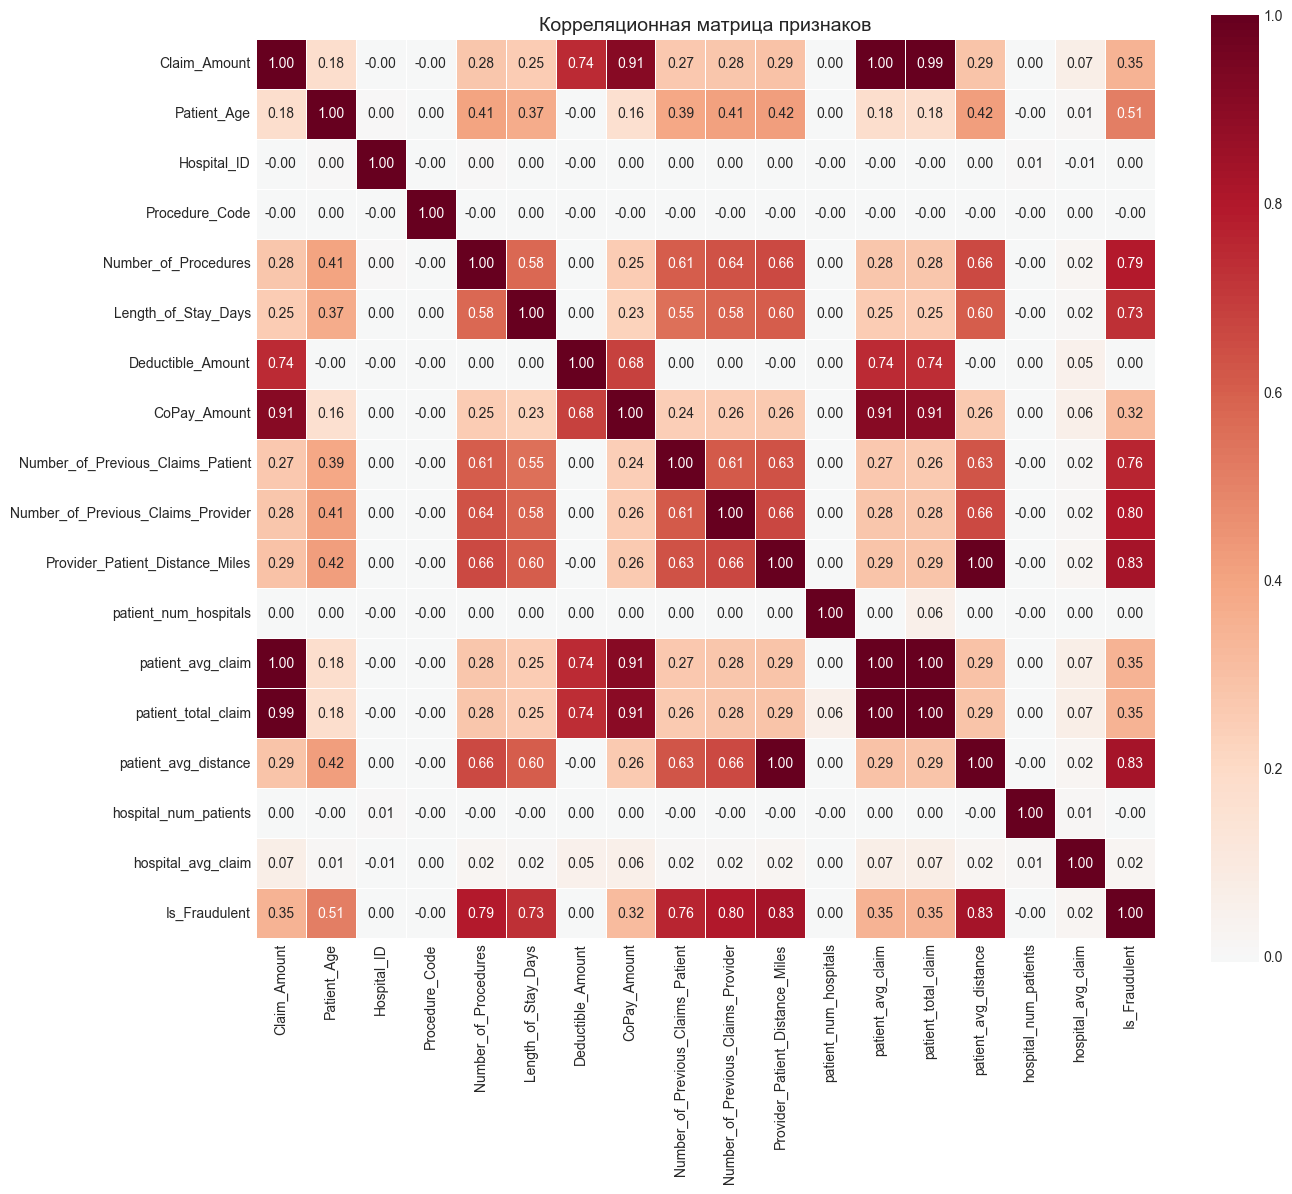


Корреляция с целевой переменной Is_Fraudulent:
   Provider_Patient_Distance_Miles: 0.829
   patient_avg_distance: 0.827
   Number_of_Previous_Claims_Provider: 0.800
   Number_of_Procedures: 0.795
   Number_of_Previous_Claims_Patient: 0.762
   Length_of_Stay_Days: 0.726
   Patient_Age: 0.510
   Claim_Amount: 0.349
   patient_avg_claim: 0.348
   patient_total_claim: 0.346
   CoPay_Amount: 0.320
   hospital_avg_claim: 0.023
   Hospital_ID: 0.002
   patient_num_hospitals: 0.001
   Deductible_Amount: 0.000
   Procedure_Code: -0.001
   hospital_num_patients: -0.002


In [22]:
print("6. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
all_numeric = numeric_features + all_graph_features + ['Is_Fraudulent']
all_numeric = [col for col in all_numeric if col in df_analysis.columns]
corr_matrix = df_analysis[all_numeric].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()
print("\nКорреляция с целевой переменной Is_Fraudulent:")
corr_with_target = corr_matrix['Is_Fraudulent'].sort_values(ascending=False)
for feat, corr_val in corr_with_target.items():
    if feat != 'Is_Fraudulent':
        print(f"   {feat}: {corr_val:.3f}")

## 10. Выбор моделей и метрик для оценки качества

Обоснование выбора моделей и метрик для дальнейшего моделирования.

In [23]:
print("7. ВЫБОР МОДЕЛЕЙ И МЕТРИК")

models_table = pd.DataFrame({
    'Модель': ['XGBoost', 'Random Forest', 'Logistic Regression'],
    'Обоснование': [
        'Лучший выбор для табличных данных, устойчив к выбросам, дает важность признаков',
        'Баггинг-ансамбль, не требует масштабирования, устойчив к переобучению',
        'Базовый бенчмарк, интерпретируемость коэффициентов'
    ],
    'Требует масштабирования': ['Нет', 'Нет', 'Да']
})

print(models_table.to_string(index=False))
print("ВЫБОР МЕТРИК")
metrics_table = pd.DataFrame({
    'Метрика': ['F1-Score', 'ROC-AUC', 'Precision', 'Recall', 'Confusion Matrix'],
    'зачем она нам': [
        'Баланс точности и полноты',
        'Разделяющая способность модели',
        'Минимизация ложных обвинений',
        'Максимальный охват мошенников',
        'Визуальный анализ ошибок'
    ]
})
print(metrics_table.to_string(index=False))

7. ВЫБОР МОДЕЛЕЙ И МЕТРИК
             Модель                                                                     Обоснование Требует масштабирования
            XGBoost Лучший выбор для табличных данных, устойчив к выбросам, дает важность признаков                     Нет
      Random Forest           Баггинг-ансамбль, не требует масштабирования, устойчив к переобучению                     Нет
Logistic Regression                              Базовый бенчмарк, интерпретируемость коэффициентов                      Да
ВЫБОР МЕТРИК
         Метрика                  зачем она нам
        F1-Score      Баланс точности и полноты
         ROC-AUC Разделяющая способность модели
       Precision   Минимизация ложных обвинений
          Recall  Максимальный охват мошенников
Confusion Matrix       Визуальный анализ ошибок


## 11. Итоговые выводы EDA

In [24]:
print("Итоговые выводы по разведке:")

print(f"""
### Статистика
- **Всего заявок:** {df.shape[0]:,}
- **Мошеннических:** {fraud_counts[1]:,} ({fraud_pct[1]:.1f}%)
- **Честных:** {fraud_counts[0]:,} ({fraud_pct[0]:.1f}%)
- **Средняя сумма заявки:** ${df['Claim_Amount'].mean():.2f}
""")

print("### Ключевые признаки, связанные с мошенничеством:")
top_features = corr_with_target[corr_with_target.index != 'Is_Fraudulent'].head(5)
for feat, corr_val in top_features.items():
    print(f"   {feat}: {corr_val:.3f}")

print("""
### Какие выводы мы можем сделать по созданным сетевым признакам:
""")

for col in all_graph_features:
    if col in df_analysis.columns:
        fraud_median = df_analysis[df_analysis['Is_Fraudulent'] == 1][col].median()
        legit_median = df_analysis[df_analysis['Is_Fraudulent'] == 0][col].median()
        print(f"   {col}: мошенники {fraud_median:.1f} vs честные {legit_median:.1f}")

print("""
### Специфические особенности медицинского фрод-датасета:
1. **Скрытые связи** — мошенничество проявляется в аномальных паттернах связей
2. **Эффект "Соседа"** — если пациент А подозрителен, риск для Б возрастает
3. **Географические аномалии** — большое расстояние "пациент-провайдер"
### Что касаемо моделирования и сравнения:
- **Признаки:** табличные признаки + графовые мета-признаки
- **Целевая переменная:** `Is_Fraudulent`
- **Метрика:** F1-Score и ROC-AUC
- **Модели:** XGBoost, Random Forest, Logistic Regression

""")


print("На этом этап с EDA закончен")


Итоговые выводы по разведке:

### Статистика
- **Всего заявок:** 1,000,000
- **Мошеннических:** 500,000 (50.0%)
- **Честных:** 500,000 (50.0%)
- **Средняя сумма заявки:** $55097.40

### Ключевые признаки, связанные с мошенничеством:
   Provider_Patient_Distance_Miles: 0.829
   patient_avg_distance: 0.827
   Number_of_Previous_Claims_Provider: 0.800
   Number_of_Procedures: 0.795
   Number_of_Previous_Claims_Patient: 0.762

### Какие выводы мы можем сделать по созданным сетевым признакам:

   patient_num_hospitals: мошенники 1.0 vs честные 1.0
   patient_avg_claim: мошенники 51239.8 vs честные 13459.1
   patient_total_claim: мошенники 51684.8 vs честные 13529.6
   patient_avg_distance: мошенники 597.9 vs честные 100.7
   hospital_num_patients: мошенники 201.0 vs честные 201.0
   hospital_avg_claim: мошенники 54674.8 vs честные 54340.3

### Специфические особенности медицинского фрод-датасета:
1. **Скрытые связи** — мошенничество проявляется в аномальных паттернах связей
2. **Эффект "Сос